## Model Evaluation

### Notebook Objectives
- Selection of the best-performing model
- Feature importance analysis of the selected model
- Error analysis using residuals of the best model

In [1]:
# Projekt-Root zum Pfad hinzufügen
import sys
sys.path.append("..") # damit src/ Module gefunden werden

In [2]:
# Imports & Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error

from src.evaluate import load_best_model, load_predictions

In [3]:
# Bestes Modell und Vorhersagen laden

model, best_key, best_metrics = load_best_model()
print("Bestes Modell:", best_key)
print("Metriken:", best_metrics)

pred_df = load_predictions(best_key)  # enthält y_true, y_pred (im Original-Raum)
pred_df.head()


Vorhersagen geladen: rf (models/predictions_rf.csv) – 3000 Zeilen
Vorhersagen geladen: rf_log (models/predictions_rf_log.csv) – 3000 Zeilen
Vorhersagen geladen: xgb_log (models/predictions_xgb_log.csv) – 3000 Zeilen

Bestes Modell (nach RMSE): rf_log (RMSE=64.77)
Modell geladen: rf_log (models/rf_log_pipeline.pkl)
Bestes Modell: rf_log
Metriken: {'rmse': np.float64(64.77010109522897), 'mae': 43.749461411565434, 'r2': 0.3780171585244666}


,y_true,y_pred
0,178.0,246.478003
1,114.0,126.923799
2,260.0,190.238883
3,98.0,128.308313
4,162.0,129.868046


In [4]:
# Feature Importance analysieren

best_model = model  # nur zur Klarheit

preprocess = best_model.named_steps["preprocess"]
preprocess.transformers_


[('num',
  Pipeline(steps=[('scaler', StandardScaler())]),
  ['minimum_nights',
   'number_of_reviews',
   'review_scores_rating',
   'latitude',
   'longitude',
   'amenity_count']),
 ('cat',
  Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))]),
  ['neighbourhood', 'room_type'])]

In [5]:
# Saubere Feature-Namen extrahieren

# Numerische Features 
num_features = preprocess.transformers_[0][2]

# Kategorische Features (OneHotEncoder)
cat_pipeline = preprocess.transformers_[1][1]
onehot = cat_pipeline.named_steps["onehot"]
cat_features = onehot.get_feature_names_out(
    preprocess.transformers_[1][2]
)

# Gesamte Feature-Liste
feature_names = list(num_features) + list(cat_features)

print(f"Anzahl Features nach OneHot-Encoding: {len(feature_names)}")
print(feature_names[:10])

Anzahl Features nach OneHot-Encoding: 25
['minimum_nights', 'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude', 'amenity_count', 'neighbourhood_I Centro Storico', 'neighbourhood_II Parioli/Nomentano', 'neighbourhood_III Monte Sacro', 'neighbourhood_IV Tiburtina']


In [6]:
# Feature Importances aus bestem Modell extrahieren

estimator = best_model.named_steps["model"]

if not hasattr(estimator, "feature_importances_"):
    raise AttributeError("Modell unterstützt keine feature_importances_")

importances = estimator.feature_importances_
print(f"Anzahl Feature Importances: {len(importances)}")

Anzahl Feature Importances: 25


In [7]:
# Sanity-Check
assert len(importances) == len(feature_names), "Feature-Namen und Importances haben unterschiedliche Länge!"

In [8]:
# Feature Importances in DataFrame zusammenfassen und sortieren

feature_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(20)

print(feature_importance_df.columns)


Index(['Feature', 'Importance'], dtype='object')


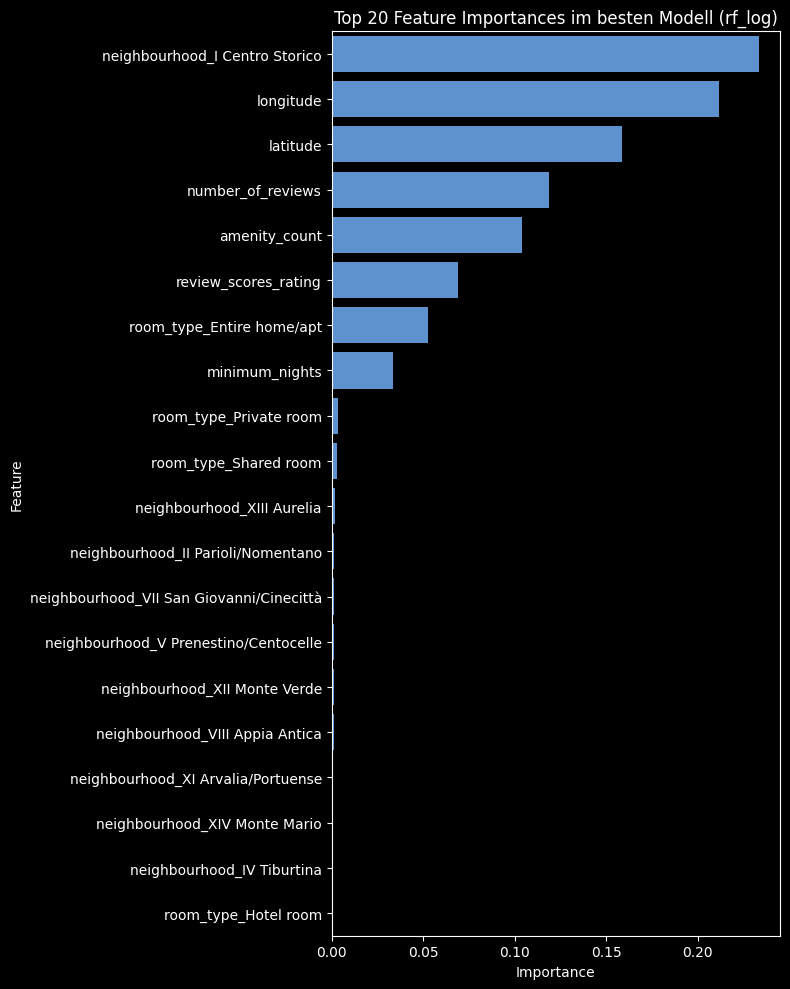

In [9]:
# Feature Importances visualisieren (Top n)

top_n = 20
plt.figure(figsize=(8, 10))

sns.barplot(
    data=feature_importance_df.head(top_n), 
    x="Importance", 
    y="Feature", 
    color="#4A90E2"
)
plt.title(f"Top {top_n} Feature Importances im besten Modell ({best_key})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

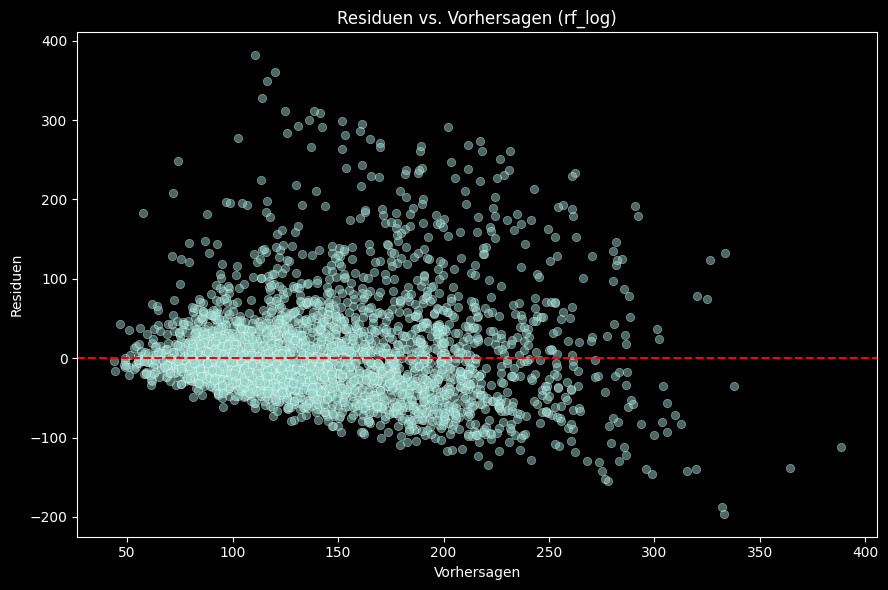

In [10]:
# Residuen analysieren

# Residuen berechnen
best_pred_df = pred_df.copy()  # umbenennen für Klarheit
best_pred_df["residual"] = best_pred_df["y_true"] - best_pred_df["y_pred"]

# Residuen vs. Vorhersagen

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=best_pred_df, 
    x="y_pred", 
    y="residual",
    alpha=0.5
)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuen vs. Vorhersagen ({best_key})")
plt.xlabel("Vorhersagen")
plt.ylabel("Residuen")
plt.tight_layout()
plt.show()


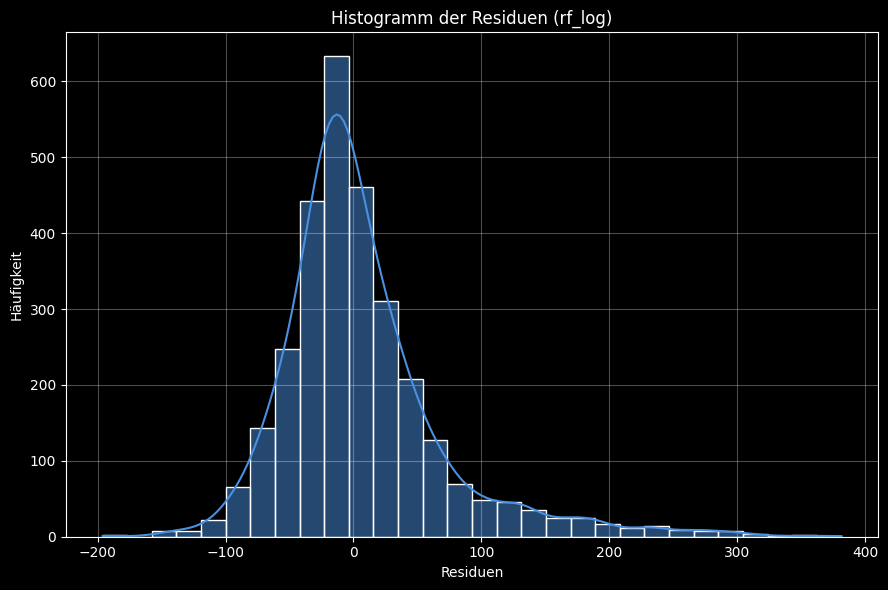

In [11]:
# Histogramm der Residuen

plt.figure(figsize=(9, 6))
sns.histplot(best_pred_df["residual"], bins=30, kde=True, color="#4A90E2")
plt.title(f"Histogramm der Residuen ({best_key})")
plt.xlabel("Residuen")
plt.ylabel("Häufigkeit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

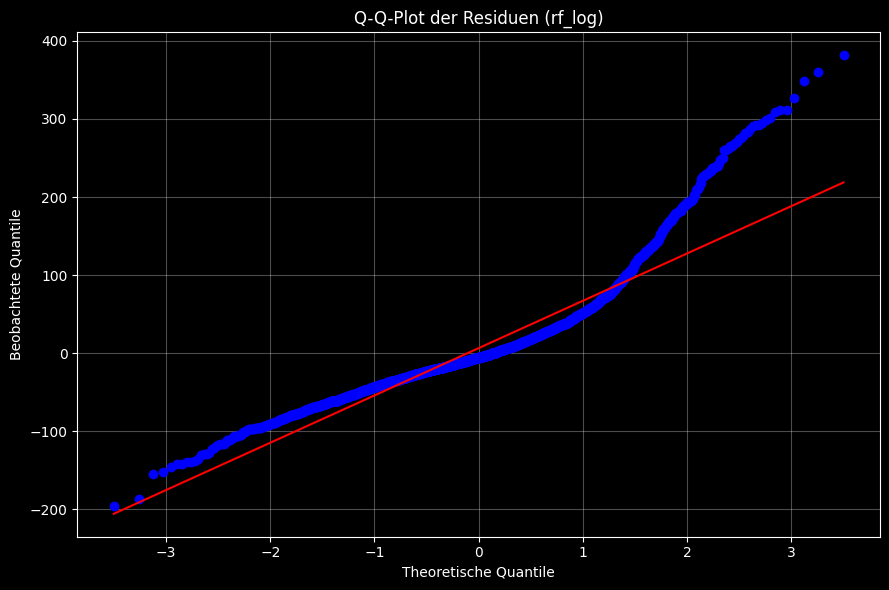

In [12]:
# Q-Q-Plot der Residuen

plt.figure(figsize=(9, 6))
stats.probplot(best_pred_df["residual"], dist="norm", plot=plt)
plt.title(f"Q-Q-Plot der Residuen ({best_key})")
plt.xlabel("Theoretische Quantile")
plt.ylabel("Beobachtete Quantile")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Performance nach Preis-Qantilen

best_pred_df["price_quantile"] = pd.qcut(
    best_pred_df["y_true"],
    q=5,
    labels=["q1", "q2", "q3", "q4", "q5"]
)

performance_by_quantile = best_pred_df.groupby(
    "price_quantile",
    observed=False
).apply(
    lambda df: pd.Series({
        "N": len(df),
        "Min": df["y_true"].min(),
        "Median": df["y_true"].median(),
        "Mean": df["y_true"].mean(),
        "Max": df["y_true"].max(),
        "RMSE": np.sqrt(mean_squared_error(df["y_true"], df["y_pred"])),
        "MAE": np.mean(np.abs(df["y_true"] - df["y_pred"])),
        "Mean Residual": np.mean(df["residual"]),
    }),
    include_groups=False
)

performance_by_quantile

,N,Min,Median,Mean,Max,RMSE,MAE,Mean Residual
price_quantile,,,,,,,,
q1,612.0,28.0,72.5,69.972222,86.0,35.671703,28.377945,-27.240998
q2,601.0,87.0,101.0,100.928453,114.0,35.629529,26.272865,-18.608060
q3,594.0,115.0,130.0,129.907407,147.0,44.351287,33.985770,-14.364458
q4,598.0,148.0,171.0,171.974916,203.0,43.340818,34.862217,4.455713
q5,595.0,204.0,259.0,284.319328,496.0,121.282224,95.892330,88.967387


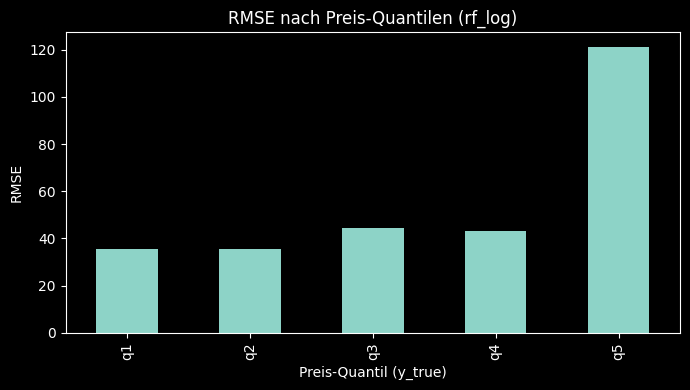

In [14]:
# RSME nach Preis-Qantilen visualisieren

performance_by_quantile["RMSE"].plot(kind="bar", figsize=(7, 4))
plt.ylabel("RMSE")
plt.xlabel("Preis-Quantil (y_true)")
plt.title(f"RMSE nach Preis-Quantilen ({best_key})")
plt.tight_layout()
plt.show()


In [15]:
# Weitere Analyse 
# RSME steigt mit Preis-Quantilen, was darauf hindeutet, dass das Modell bei höheren Preisen schlechtere Vorhersagen liefert.
# Mean Residual deutet zudem auf Bias hin, da die Residuen für q1 bis q3 negativ (d.h. Preise werden überschätzt) und für q5 positiv (d.h. Preise werden unterschätzt) sind.
# Preisspannweite von q5 sehr hoch, daher weitere Analyse der Residuen in q5.

q5_df = best_pred_df[
    best_pred_df["price_quantile"] == "q5"
].copy()

print(q5_df["y_true"].describe())

q5_df["q5_subquantile"] = pd.qcut(
    q5_df["y_true"],
    q=4,
    labels=["q5_1", "q5_2", "q5_3", "q5_4"]
)

q5_analysis = q5_df.groupby(
    "q5_subquantile",
    observed=False
).apply(
    lambda df: pd.Series({
        "N": len(df),
        "Min": df["y_true"].min(),
        "Median": df["y_true"].median(),
        "Mean": df["y_true"].mean(),
        "Max": df["y_true"].max(),
        "RMSE": np.sqrt(mean_squared_error(df["y_true"], df["y_pred"])),
        "MAE": np.mean(np.abs(df["y_true"] - df["y_pred"])),
        "Mean Residual": np.mean(df["residual"]),
    }),
    include_groups=False
)

q5_analysis

count    595.000000
mean     284.319328
std       74.173735
min      204.000000
25%      227.000000
50%      259.000000
75%      320.000000
max      496.000000
Name: y_true, dtype: float64


,N,Min,Median,Mean,Max,RMSE,MAE,Mean Residual
q5_subquantile,,,,,,,,
q5_1,150.0,204.0,214.0,214.280000,227.0,58.457689,47.976022,31.955465
q5_2,149.0,228.0,240.0,242.355705,259.0,68.392597,56.688604,48.104594
q5_3,149.0,260.0,285.0,285.939597,320.0,102.149085,90.771562,87.830353
q5_4,147.0,321.0,395.0,396.680272,496.0,201.824993,189.714071,189.714071


## Conclusion

### Model Comparison
- Evaluated models show very similar performance when measured by RMSE.
- Log transformation of the target variable leads to only a modest improvement in overall model performance.

### Feature Importance
- Proximity to the city center is the most important price driver
- Property characteristics are of secondary importance  
  (exception: private vs. shared accommodations)
- The number of reviews appears among the most important features,  
  while the review score itself does not
- The number of amenities is not among the most important features

### Residual Analysis
- Residuals are approximately normally distributed, with noticeable right-sided fat tails.
- The error analysis reveals a pronounced deterioration in prediction performance toward the upper end of the price distribution. 
- Within the highest price quintile, RMSE increased from 58.5 in the lowest Q5 sub-quantile to 201.8 in the highest, while mean residuals increased from 32.0 to 189.7. 
- This indicates that the global model tends to systematically underestimate high-priced listings and motivates the investigation of specialized price-segment models.


### Future Analysis

- Extract more detailed features (e.g., specific amenities), particularly to improve predictions for high-priced listings
- Evaluate models specialized for categorical variables (e.g., CatBoost)
- Explore segmented modeling approaches (e.g., mixture-of-experts) to investigate whether price-specific expert models can improve predictions